# Vectorized Classification Models

## Emotion Face Classifier

In [2]:
import os
import pandas as pd

In [3]:
def check_directory_name(target_name) -> bool:
    """
    Check if the current directory name matches the target_name.
    If not, move up a directory and repeat the check.
    
    Args:
        target_name (str): The directory name to match.
        
    Returns:
        bool: True if the current directory name matches the target_name, False otherwise.
    """
    # Get the current directory path
    current_dir = os.getcwd()
    
    # Extract the directory name from the path
    current_dir_name = os.path.basename(current_dir)
    
    # Check if the current directory name matches the target_name
    if current_dir_name == target_name:
        print(f'Directory set to {current_dir}, matches target dir sting {target_name}.')
        return True
    else:
        # Move up a directory
        os.chdir('..')
        # Check if we have reached the root directory
        if os.getcwd() == current_dir:
            return False
        # Recursively call the function to check the parent directory
        return check_directory_name(target_name)

In [4]:
main_dir = 'EmotionFaceClassifier'
check_directory_name(main_dir)

Directory set to /Users/dsl/Documents/GitHub/EmotionFaceClassifier, matches target dir sting EmotionFaceClassifier.


True

In [5]:
from src.helpers import (
    load_config
)

In [6]:
df_path = 'data/efc2024.csv'
df = pd.read_csv(df_path)

In [7]:
# Load model params from JSON
flat_models = load_config('./configs/vectorized_models.json')
print(flat_models.keys())

dict_keys(['LGBM', 'LogisticRegression', 'DecisionTree', 'RandomForest', 'XGBoost'])


In [15]:
df.columns

Index(['Unnamed: 0', 'train_test_split', 'emotion', 'Filename', 'Full Path',
       'source'],
      dtype='object')

In [17]:
df.train_test_split.unique()

array(['Training', 'Testing'], dtype=object)

In [ ]:
train_df = df[df['train_test_split']=='Train']
X_train = np.stack(train_df['flat_array'].values)
# NOTE: Some models require int labels
y_train = train_df['emotion_id']

In [18]:
train_df = df[df['train_test_split']=='Train']
X_train = np.stack(train_df['flat_array'].values)
# NOTE: Some models require int labels
y_train = train_df['emotion_id']

In [20]:
# Create output dir
flat_model_dir = os.path.join('models', 'flat')
os.makedirs(flat_model_dir, exist_ok=True)

In [21]:
# Set paths for split data and settings
X_train_path = os.path.join(flat_model_dir, 'train_df.csv')
y_train_path = os.path.join(flat_model_dir, 'y_train.csv')
model_config_path = os.path.join(flat_model_dir, 'model_config.json')

In [22]:
# Save copy of split data and settings to model directory
train_df.to_csv(X_train_path, index=False)
y_train.to_csv(y_train_path, index=False)
to_json(flat_models, model_config_path)

## Flat Array Models

Trains each model specified in './configs/flat_models.json'

See flat_models dictionary for more details.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [25]:
flat_models

{'LGBM': {'module': 'lightgbm', 'class': 'LGBMClassifier', 'params': {}},
 'LogisticRegression': {'module': 'sklearn.linear_model',
  'class': 'LogisticRegression',
  'params': {'multi_class': 'multinomial', 'max_iter': 500}},
 'DecisionTree': {'module': 'sklearn.tree',
  'class': 'DecisionTreeClassifier',
  'params': {}},
 'RandomForest': {'module': 'sklearn.ensemble',
  'class': 'RandomForestClassifier',
  'params': {}},
 'XGBoost': {'module': 'xgboost',
  'class': 'XGBClassifier',
  'params': {'eval_metric': 'mlogloss'}}}

In [26]:
models = create_models(flat_models)

In [27]:
flat_models

{'LGBM': {'module': 'lightgbm', 'class': 'LGBMClassifier', 'params': {}},
 'LogisticRegression': {'module': 'sklearn.linear_model',
  'class': 'LogisticRegression',
  'params': {'multi_class': 'multinomial', 'max_iter': 500}},
 'DecisionTree': {'module': 'sklearn.tree',
  'class': 'DecisionTreeClassifier',
  'params': {}},
 'RandomForest': {'module': 'sklearn.ensemble',
  'class': 'RandomForestClassifier',
  'params': {}},
 'XGBoost': {'module': 'xgboost',
  'class': 'XGBClassifier',
  'params': {'eval_metric': 'mlogloss'}}}

In [28]:
model_metrics = []

Running LGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.587092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 552538
[LightGBM] [Info] Number of data points in the train set: 28709, number of used features: 2304
[LightGBM] [Info] Start training from score -1.972167
[LightGBM] [Info] Start training from score -4.187324
[LightGBM] [Info] Start training from score -1.946956
[LightGBM] [Info] Start training from score -1.381048
[LightGBM] [Info] Start training from score -1.782364
[LightGBM] [Info] Start training from score -2.203164
[LightGBM] [Info] Start training from score -1.754797
Running LogisticRegression model...


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Running DecisionTree model...
Running RandomForest model...
Running XGBoost model...


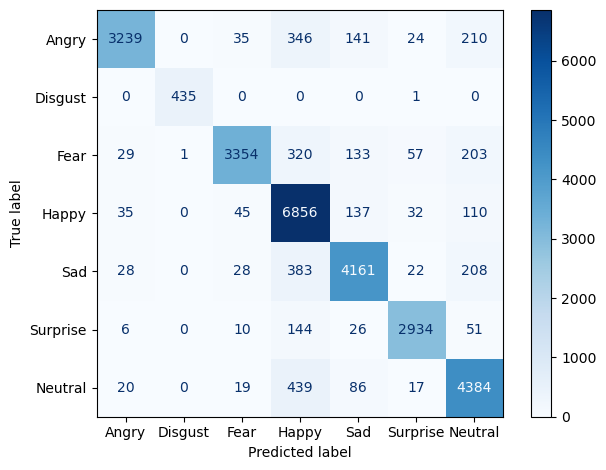

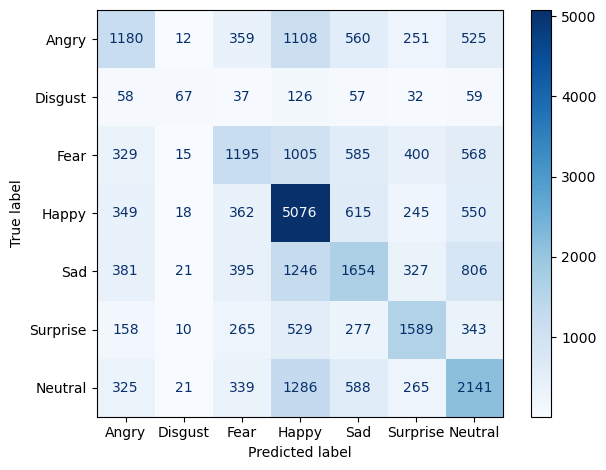

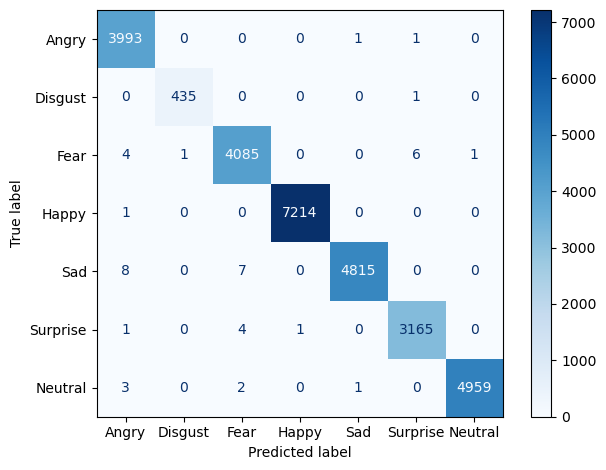

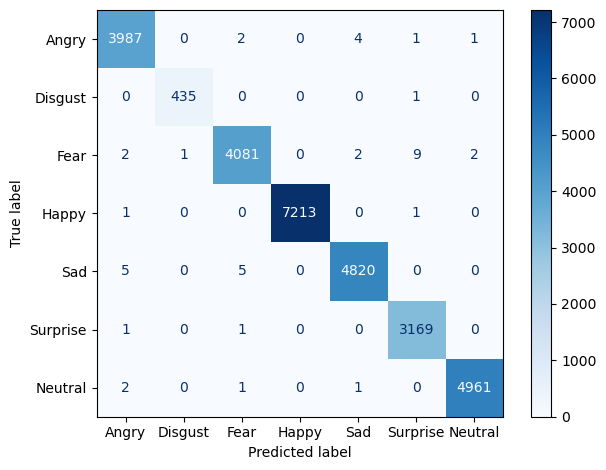

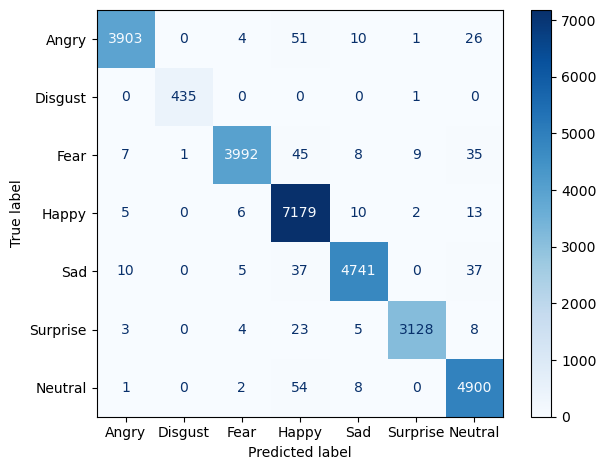

In [29]:
for label, model in models.items():
    print(f"Running {label} model...")    
    # Set dirs and filepaths
    model_output_dir = os.path.join(flat_model_dir, label)
    model_output_path = os.path.join(model_output_dir, 'mdl.pkl')
    metrics_ouput_path = os.path.join(model_output_dir, 'train_metrics.csv')
    cm_ouput_path = os.path.join(model_output_dir, 'train_confusion_matrix.png')

    os.makedirs(model_output_dir, exist_ok=True)
    
    # fit, save, predict
    model.fit(X_train, y_train)
    save_model(model, filename=model_output_path)
    model_preds = model.predict(X_train)
    model_results = get_classification_metrics(y_train, model_preds)

    # Aggregate metrics and save to model dir
    pd.DataFrame(model_results, index=[0]).to_csv(metrics_ouput_path)
    model_metrics.append({label: model_results})

    # Confusion matrix
    int_labels = [int(i) for i in emo_dict.keys()]
    str_labels = [i for i in emo_dict.values()]
    
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_train,
        y_pred=model_preds, 
        cmap='Blues',
        labels=int_labels,
        display_labels=str_labels
    )    
    plt.tight_layout()
    plt.savefig(cm_ouput_path, pad_inches=5)

In [60]:
model_metrics

[{'LGBM': {'accuracy': 0.8834511825559929,
   'precision': 0.8907142342195778,
   'recall': 0.8834511825559929,
   'f1_score': 0.8837785300489234}},
 {'LogisticRegression': {'accuracy': 0.44940610958236094,
   'precision': 0.44078573117003017,
   'recall': 0.44940610958236094,
   'f1_score': 0.43627416697576776}},
 {'DecisionTree': {'accuracy': 0.9985022118499425,
   'precision': 0.998504489889346,
   'recall': 0.9985022118499425,
   'f1_score': 0.9985025015131743}},
 {'RandomForest': {'accuracy': 0.9985022118499425,
   'precision': 0.998503104246426,
   'recall': 0.9985022118499425,
   'f1_score': 0.9985022385454645}},
 {'XGBoost': {'accuracy': 0.9849872862168658,
   'precision': 0.9851549511375772,
   'recall': 0.9849872862168658,
   'f1_score': 0.9849998768587155}}]

In [64]:
pd.DataFrame.from_dict(model_metrics, orient='tight')

TypeError: list indices must be integers or slices, not str

In [82]:
test = pd.DataFrame(model_results, index=['model'])

In [76]:
test

,accuracy,precision,recall,f1_score
model,0.984987,0.985155,0.984987,0.985


In [78]:
test['m2'] = model_results

In [80]:
test

,accuracy,precision,recall,f1_score,m2
model,0.984987,0.985155,0.984987,0.985,NaN


In [30]:
# Convert all model metrics to a df
agg_df = pd.DataFrame(model_metrics)

In [31]:
# Save df
agg_df_path = os.path.join(flat_model_dir, 'aggregated_metrics.csv')
agg_df.to_csv(agg_df_path)